# The PI-DeepONet method for Parametric PDEs

## (1) Generating training data 
The Darcy's equation:
\begin{equation}
\begin{split}
-\nabla\cdot(a\nabla u) &= f \\
u &= 0
\end{split}
\end{equation}
The goal of the parametric PDE problem is to learn a mapping from the PDE coefficient $a$ to the solution $u$, i.e.,:
$$
\mathcal{G}: a(x)\in\mathcal{A}\rightarrow u(x)\in\mathcal{U}
$$
> Note: Different from DeepONet, which requires extensive $(a,u)$ pairs, the PI-DeepONet method can be trained only with $a$ and without any labeled pairs.
> 
> Datasets in the lesson are available through: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

In [ ]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from tqdm import trange
from torch.utils.data import Dataset, DataLoader
import time

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

setup_seed(3407)
device = 'cuda'
dtype = torch.float32
N_mesh = 29
######################################
# Load training data
# KEY CHANGE: We still load 'a' (the PDE coefficient) for both
# training and testing. However, 'u' (the solution) is only loaded
# for the test set to evaluate accuracy — it is NOT used during training.
######################################
data_train = h5py.File('DarcyFlow_train.mat', 'r')
data_test  = h5py.File('DarcyFlow_test.mat',  'r')

def get_data(data, ndata=1000):
    a = np.array(data["coeff"][...,:ndata]).T
    u = np.array(data["sol"][:,:ndata]).T
    x1, x2 = np.array(data['X']).T, np.array(data['Y']).T
    mesh = np.vstack([x1.ravel(), x2.ravel()]).T
    gridx = mesh.reshape(-1, 2)
    #
    a = torch.tensor(a, dtype=dtype).reshape(ndata, -1)
    u = torch.tensor(u, dtype=dtype).reshape(ndata, -1)
    x = torch.tensor(gridx, dtype=dtype)
    return a, u, x, gridx

a_train, _, x_train, _ = get_data(data_train, ndata=1000)
a_test,  u_test,  x_test,  gridx  = get_data(data_test,  ndata=200)

print('The shape of a_train:', a_train.shape)   # (1000, 841)
print('The shape of x_train:', x_train.shape)   # (841, 2)

######################################
# Visualize one training sample (coefficient a only — no u available at train time)
######################################
a_show = a_train[0]
mesh = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 200))
x_plot, y_plot = mesh[0], mesh[1]

fig, ax = plt.subplots(figsize=(6, 4))
z_plot = griddata((gridx[:,0], gridx[:,1]), np.ravel(a_show), (x_plot, y_plot), method='cubic')
cntr = ax.contourf(x_plot, y_plot, z_plot, levels=40, cmap='jet')
fig.colorbar(cntr, ax=ax)
ax.set_title('Input coefficient a (training, unlabeled)')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.show()

## (2) The DeepONet architecture 

In [2]:
######################################
# DeepONet architecture (unchanged)
######################################
class DeepONet(nn.Module):

    def __init__(self, layers_trunk, layers_branch):
        super(DeepONet, self).__init__()
        self.activation_trunk  = nn.ReLU()   
        self.activation_branch = nn.ReLU()   
        self.branch_net(layers_branch)
        self.trunk_net(layers_trunk)
        self.bias = nn.Parameter(torch.tensor(0.0, dtype=dtype))

    def branch_net(self, layers_branch):
        net, hidden_in = [], layers_branch[0]
        for hidden in layers_branch[1:-1]:
            net += [nn.Linear(hidden_in, hidden, dtype=dtype), self.activation_branch]
            hidden_in = hidden
        net.append(nn.Linear(hidden_in, layers_branch[-1], dtype=dtype))
        self.branch = nn.Sequential(*net)

    def trunk_net(self, layers_trunk):
        net, hidden_in = [], layers_trunk[0]
        for hidden in layers_trunk[1:-1]:
            net += [nn.Linear(hidden_in, hidden, dtype=dtype), self.activation_trunk]
            hidden_in = hidden
        net.append(nn.Linear(hidden_in, layers_trunk[-1], dtype=dtype))
        self.trunk = nn.Sequential(*net)

    def forward(self, x, a):
        """
        x : (M, 2)        — query coordinates
        a : (B, a_size)   — branch input (coefficient at sensor points)
        returns: (B, M)   — predicted solution values
        """
        t = self.activation_trunk(self.trunk(x))   # (M, p)
        b = self.branch(a)                          # (B, p)
        return torch.einsum("bp,mp->bm", b, t) + self.bias  # (B, M)


layers_trunk  = [x_train.shape[-1], 128, 128, 128, 128]
layers_branch = [a_train.shape[-1], 128, 128, 128, 128]
model_u = DeepONet(layers_trunk, layers_branch).to(device)
#
from torchsummary import summary
summary(model_u, [(2,), (841,)], device=device)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]             384
              ReLU-2                  [-1, 128]               0
              ReLU-3                  [-1, 128]               0
            Linear-4                  [-1, 128]          16,512
              ReLU-5                  [-1, 128]               0
              ReLU-6                  [-1, 128]               0
            Linear-7                  [-1, 128]          16,512
              ReLU-8                  [-1, 128]               0
              ReLU-9                  [-1, 128]               0
           Linear-10                  [-1, 128]          16,512
             ReLU-11                  [-1, 128]               0
             ReLU-12                  [-1, 128]               0
           Linear-13                  [-1, 128]         107,776
             ReLU-14                  [

## (3) Loss Function

### (3.1) Boundary Condition — Hard Enforcement via Ansatz

To exactly satisfy the homogeneous Dirichlet condition $u|_{\partial\Omega} = 0$, the network output is multiplied by a boundary-vanishing mask:

$$
u_\theta(\mathbf{x}; a) = \widetilde{u}_\theta(\mathbf{x}; a)\cdot\sin(\pi x_1)\sin(\pi x_2),
$$

where $\widetilde{u}_\theta$ is the raw DeepONet output (branch–trunk inner product). Since $\sin(\pi x_1)\sin(\pi x_2) = 0$ on $\partial\Omega$, the boundary condition is **built into the architecture** — no boundary penalty term is needed in the loss.

### (3.2) PDE Residual

Substituting $u_\theta$ into the Darcy equation gives the strong-form residual at any interior point $\mathbf{x} \in \Omega$:

$$
\mathcal{R}[u_\theta; a](\mathbf{x})
= -\frac{\partial}{\partial x_1}\!\left(a\frac{\partial u_\theta}{\partial x_1}\right)
  -\frac{\partial}{\partial x_2}\!\left(a\frac{\partial u_\theta}{\partial x_2}\right) - f.
$$

All partial derivatives are computed by **automatic differentiation through the trunk network** with respect to $\mathbf{x}$. This requires a smooth activation function (Tanh), since ReLU has a near-zero second derivative.

### (3.3) Total Loss Function

Given $N$ sampled input functions $\{a^{(i)}\}_{i=1}^N$ (no paired solutions needed) and $M_r$ collocation points $\{\mathbf{x}_j\}_{j=1}^{M_r}$ randomly sampled in $\Omega$, the PI-DeepONet loss is:

$$
\boxed{
\mathcal{L}(\theta)
= \frac{\lambda_r}{N \cdot M_r}
  \sum_{i=1}^{N}\sum_{j=1}^{M_r}
  \left|\mathcal{R}\bigl[u_\theta(\,\cdot\,; a^{(i)})\,;\,a^{(i)}\bigr](\mathbf{x}_j)\right|^2
}
$$

**No labeled solutions $u^{(i)}$ are required.** If a small labeled dataset is available, a supervised term can be added (semi-supervised mode):

$$
\mathcal{L}(\theta) = \lambda_r\,\mathcal{L}_{\text{PDE}} + \lambda_d\,\mathcal{L}_{\text{data}}, \qquad
\mathcal{L}_{\text{data}} = \frac{1}{N_d}\sum_{i=1}^{N_d}\bigl\|u^{(i)} - u_\theta(\,\cdot\,; a^{(i)})\bigr\|_2.
$$

Setting $\lambda_d = 0$ recovers the fully physics-informed mode.

In [3]:
###############################
# Define Loss Class
###############################
import torch.nn as nn
from torch.autograd import grad, Variable

###############################
class mollifier(object):

    def __inint__(self):
        pass
        
    def __call__(self, u, x):
        '''Define the mollifer
        Input:
            u: size(n_batch, nx)
            x: size(nx, 2)
        Output:
            u: size(n_batch, nx)
        '''
        x = x.repeat(u.shape[0],1,1)
        u = u * torch.sin(np.pi * x[...,0])*torch.sin(np.pi * x[...,1])
        return u

class LossClass(object):

    def __init__(self, u_model, lambda_r=1.0, lambda_d=0.0, 
                 sensor_grid=None):
        """
        Args:
            u_model     : DeepONet
            lambda_r    : weight for PDE residual loss
            lambda_d    : weight for supervised data loss (0 = fully physics-informed)
            sensor_grid : (N_sensor, 2) fixed sensor coordinates for a-interpolation
        """
        self.u_model     = u_model
        self.lambda_r    = lambda_r
        self.lambda_d    = lambda_d
        self.sensor_grid = sensor_grid  # (N_sensor, 2)
        self.mollifier = mollifier()
        #
        self.dx = 1/(N_mesh-1)
        self.dy = 1/(N_mesh-1)

    def loss_pde(self, a_batch):
        """
        Physics loss:  L_pde = (1/B) sum_i (1/M_r) || res_i ||^2

        Args:
            a_batch : (B, N_sensor)  — only the coefficient, NO solution needed
        """
        n_batch = a_batch.shape[0]
        ############### Data points ###############
        x = self.sensor_grid.to(a_batch)
        # x = Variable(self.sensor_grid.repeat(n_batch, 1, 1).to(a_batch), requires_grad=True)
        u = self.u_model(x, a_batch)
        u = self.mollifier(u, x).reshape(-1, N_mesh, N_mesh)
        a = a_batch.reshape(n_batch, N_mesh, N_mesh)
        #
        dudx = (u[:, 1:-1, 2:] - u[:, 1:-1, :-2]) /self.dx/2
        dudy = (u[:, 2:, 1:-1] - u[:, :-2, 1:-1]) /self.dy/2
        adux = a[:,1:-1,1:-1] * dudx # size(batch_size, my_size-2, mx_size-2)
        aduy = a[:,1:-1,1:-1] * dudy # size(batch_size, my_size-2, mx_size-2)
        #
        dauxdx = (adux[:, 1:-1, 2:] - adux[:, 1:-1, :-2]) /self.dx/2 # size(batch_size, my_size-4, mx_size-4, 1)
        dauydy = (aduy[:, 2:, 1:-1] - aduy[:, :-2, 1:-1]) /self.dy/2 # size(batch_size, my_size-4, mx_size-4, 1)
        #############################################
        left = (- (dauxdx + dauydy)).reshape(n_batch, -1)
        # default size of f: size(n_batch, nx-2 * ny -2)
        right = 10. * torch.ones_like(left)
        loss = torch.norm(left - right, 2, dim=1)
        return torch.mean(loss)

    def loss_data(self, a_batch, u_batch, x):
        """
        Supervised loss on labeled pairs (a, u).
        Identical to the original DeepONet data loss.
        """
        u_pred = self.u_model(x, a_batch)
        u_pred = self.mollifier(u_pred, x)
        loss = torch.norm(u_batch - u_pred, 2, dim=1)
        return torch.mean(loss)

    def loss_total(self, a_batch, u_batch=None, x=None):
        """
        Total loss = lambda_r * L_pde  [+ lambda_d * L_data]
        Set lambda_d=0 (default) for the fully physics-informed mode.
        """
        loss = self.lambda_r * self.loss_pde(a_batch)
        if self.lambda_d > 0 and u_batch is not None and x is not None:
            loss = loss + self.lambda_d * self.loss_data(a_batch, u_batch, x)
        return loss

    def get_error(self, a, u, x):
        """L2 relative error — uses labeled test pairs for evaluation only."""
        u_pred = self.u_model(x, a)
        u_pred = self.mollifier(u_pred, x)
        error  = torch.norm(u - u_pred, 2, dim=1) / torch.norm(u, 2, dim=1)
        return torch.mean(error)

### (4) Training the model

In [4]:
######################################
# Dataset
#
# The PI-DeepONet dataset only needs 'a' during training.
# 'u' is stored but not passed to the loss — set include_u=False
# for the fully unsupervised mode.
######################################
class MyDataset(Dataset):
    def __init__(self, a: torch.Tensor, u: torch.Tensor = None):
        self.a = a
        self.u = u   # may be None in the purely physics-informed case

    def __getitem__(self, index):
        if self.u is not None:
            return self.a[index], self.u[index]
        return (self.a[index],)

    def __len__(self):
        return self.a.shape[0]


######################################
# Training
#
# PI-DeepONet mode: set lambda_d=0.0 (no labeled u used during training).
# Semi-supervised mode: set lambda_d > 0 and pass u_batch into loss_total.
######################################
LAMBDA_R = 1.0    # PDE residual weight
LAMBDA_D = 0.0    # Data loss weight — set > 0 for semi-supervised

# Fully physics-informed: dataset holds only 'a' (u not passed to loss)
train_dataset = MyDataset(a_train)   # no u_train — unsupervised
train_loader  = DataLoader(train_dataset, batch_size=50, shuffle=True)

lossClass = LossClass(
    u_model=model_u,
    lambda_r=LAMBDA_R,
    lambda_d=LAMBDA_D,
    sensor_grid=x_train.to(device),  # fixed sensor grid for a-interpolation
)

epochs    = 2000
lr        = 1e-3
optimizer = torch.optim.Adam(model_u.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=np.int32(epochs/6), gamma=0.5)

loss_list, error_list = [], []
t0 = time.time()

for epoch in trange(epochs):
    model_u.train()
    epoch_loss = 0.0

    for batch in train_loader:
        # Unpack — only 'a' in the fully PI mode
        a_batch = batch[0].to(device)

        # --- PI loss (PDE residual only; no u_batch needed) ---
        loss_train = lossClass.loss_total(a_batch)

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        epoch_loss += loss_train.item()

    scheduler.step()

    # Evaluate on labeled test set (for monitoring only)
    model_u.eval()
    with torch.no_grad():
        error = lossClass.get_error(
            a_test.to(device), u_test.to(device), x_test.to(device)
        )
        error_list.append(error.item())

    epoch_loss /= len(train_loader)
    loss_list.append(epoch_loss)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d} | PDE loss: {epoch_loss:.4e} '
              f'| Test L2 rel. error: {error_list[-1]:.4e}')

print(f'\nTotal training time: {time.time() - t0:.1f}s')

  5%|███▎                                                             | 101/2000 [00:12<03:48,  8.30it/s]

Epoch  100 | PDE loss: 1.4162e+01 | Test L2 rel. error: 2.9846e-02


 10%|██████▌                                                          | 201/2000 [00:24<03:36,  8.30it/s]

Epoch  200 | PDE loss: 1.0234e+01 | Test L2 rel. error: 1.5997e-02


 15%|█████████▊                                                       | 301/2000 [00:36<03:24,  8.29it/s]

...

Epoch 1800 | PDE loss: 3.3964e+00 | Test L2 rel. error: 8.5899e-03


 95%|████████████████████████████████████████████████████████████▊   | 1901/2000 [03:49<00:11,  8.32it/s]

Epoch 1900 | PDE loss: 3.3604e+00 | Test L2 rel. error: 7.6504e-03


100%|████████████████████████████████████████████████████████████████| 2000/2000 [04:01<00:00,  8.29it/s]

Epoch 2000 | PDE loss: 3.3061e+00 | Test L2 rel. error: 8.6888e-03

Total training time: 241.3s


## (5) Performance on testing dataset
The relative error:
$$
L^2 = \sqrt{\sum_i\frac{\|u(x_i)-u_{nn}(x_i)\|^2}{\|u(x_i)\|^2}}
$$
where $u$ represents the true solution and $u_{nn}$ is the network approximation.

The average l2 error: tensor(0.0087)


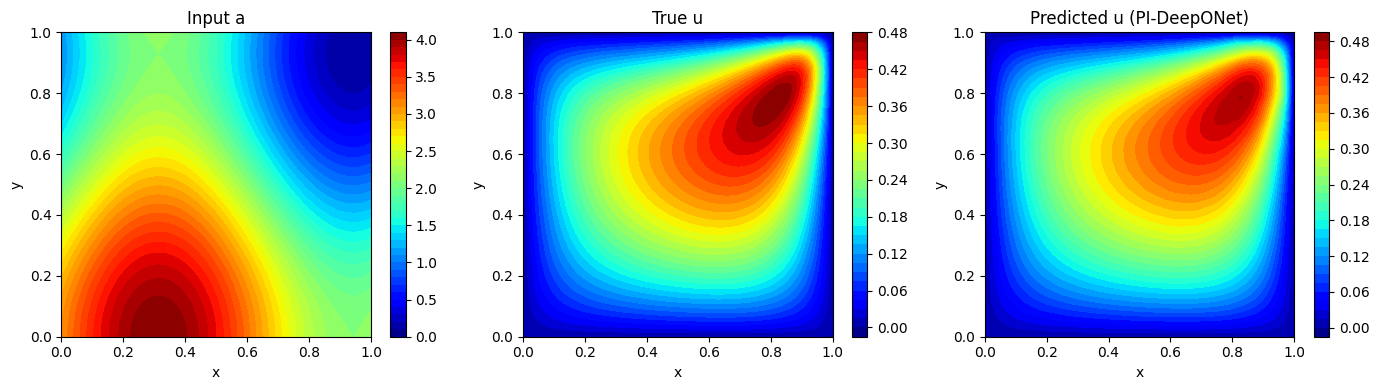

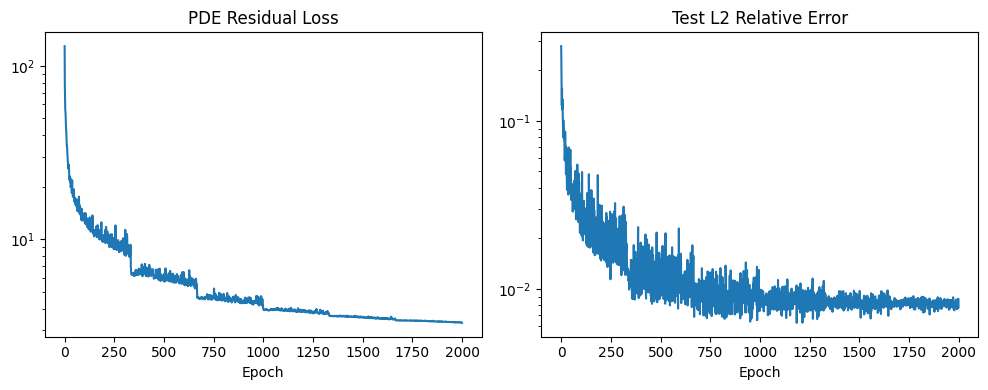

In [5]:
#######################################
# The L2 relative error
#######################################
def L2_error(u, u_pred):
    ''' '''
    l2 = torch.norm(u-u_pred, 2, 1) / torch.norm(u, 2, 1)
    return l2
######################################
# Visualise predictions vs ground truth (test sample)
######################################
model_u.eval()
with torch.no_grad():
    u_pred_all = model_u(x_test.to(device), a_test.to(device))
    u_pred_all = mollifier()(u_pred_all, x_test.to(device)).cpu()
# compute the L2 relative error
l2_err = L2_error(u_test, u_pred_all)
print('The average l2 error:', torch.mean(l2_err))

sample_idx = 0
a_show, u_show, u_pred_show = (a_test[sample_idx], u_test[sample_idx],
                                u_pred_all[sample_idx])

mesh_plot = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 200))
x_plot, y_plot = mesh_plot[0], mesh_plot[1]

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for ax, vals, title in zip(axs,
                            [a_show, u_show, u_pred_show],
                            ['Input a', 'True u', 'Predicted u (PI-DeepONet)']):
    z = griddata((gridx[:,0], gridx[:,1]), vals.numpy(), (x_plot, y_plot), method='cubic')
    cntr = ax.contourf(x_plot, y_plot, z, levels=40, cmap='jet')
    fig.colorbar(cntr, ax=ax)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

######################################
# Training curves
######################################
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].semilogy(loss_list);  axs[0].set_title('PDE Residual Loss'); axs[0].set_xlabel('Epoch')
axs[1].semilogy(error_list); axs[1].set_title('Test L2 Relative Error'); axs[1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()